<a href="https://colab.research.google.com/github/MohammadYusif/time-series-forecasting-ai-systems/blob/main/day3/06_lab_model_comparison.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>


## Lab 6 — Comparing Model Families Across All Four Datasets

Objective 7 asks: given a forecasting problem, which model family should
you reach for? Labs 1-5 built and tuned models one dataset at a time. This
lab runs the SAME three models — seasonal-naive, Holt-Winters, and a
recursive LightGBM — across ALL FOUR of the course's golden-thread
datasets, so the comparison in `06_model_comparison.qmd`'s decision
framework is backed by real backtest numbers, not intuition.

Deliberately excluded here: Prophet and sktime. Lab 5 already covered
probabilistic forecasting with those libraries in depth — this lab's job
is breadth across data shapes (long daily history, a structural break,
short monthly history, sparse intermittent demand), not re-running heavy
libraries a second time.

For each dataset we pick fold sizing appropriate to that series' length
and character (see the markdown above the backtest cell), run all three
models with `expanding_window_splits` + `run_backtest`, score every fold
with `mae`, `wape`, and `mase`, and read off which model wins where — and,
for the workforce series specifically, whether any model's backtest
performance holds up through the 2025-04-01 structural break.

### Setup

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "scikit-learn", "lightgbm", "statsmodels")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path
    — labs live one directory below the repo root) or download it from
    GitHub if neither exists (a fresh Colab runtime)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width
sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)

import warnings
warnings.filterwarnings("ignore")

### Load and prepare the four series

Each dataset is reduced to a single univariate array so the comparison across datasets is apples-to-apples in shape.

In [2]:
# Riyadh/Grocery — the Day 1/Day 2 running example (daily, weekly seasonality)
retail = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
retail_series = (
    retail[(retail.region == "Riyadh") & (retail.category == "Grocery")]
    .sort_values("date")["units_sold"]
    .to_numpy(dtype=float)
)

# Contact-centre headcount — daily, weekly seasonality, a structural break
# on 2025-04-01 (a sustained ~35% step up in required headcount).
workforce = pd.read_csv(fetch("data/workforce_demand.csv"), parse_dates=["date"])
workforce = workforce.sort_values("date").reset_index(drop=True)
workforce_series = workforce["required_headcount"].to_numpy(dtype=float)
BREAK_DATE = pd.Timestamp("2025-04-01")
BREAK_INDEX = int((workforce["date"] < BREAK_DATE).sum())

# Non-oil activity index — monthly, only 108 points of history.
econ = pd.read_csv(fetch("data/economic_indicator.csv"), parse_dates=["month"])
econ = econ.sort_values("month").reset_index(drop=True)
econ_series = econ["activity_index"].to_numpy(dtype=float)

# Spare-parts demand — 4 SKUs, ~95% zero rows individually. We sum across
# SKUs into one daily total so all four series in this lab are a single
# univariate array of the same shape. This is a simplification: it hides
# the per-SKU sparsity (the total is far less zero-heavy than any one SKU)
# — forecasting each SKU on its own is the harder, more realistic version
# of this problem and is out of scope here.
intermittent = pd.read_csv(fetch("data/intermittent_demand.csv"), parse_dates=["date"])
intermittent_total = (
    intermittent.groupby("date")["units_ordered"].sum().sort_index()
)
intermittent_series = intermittent_total.to_numpy(dtype=float)

print("retail_series      ", retail_series.shape, "starts", retail["date"].min().date())
print("workforce_series   ", workforce_series.shape, "starts", workforce["date"].min().date(),
      "| break at index", BREAK_INDEX, f"({BREAK_DATE.date()})")
print("econ_series        ", econ_series.shape, "starts", econ["month"].min().date())
print("intermittent_series", intermittent_series.shape, "starts", intermittent_total.index.min().date(),
      "| zero rate", round((intermittent_series == 0).mean(), 3))

retail_series       (1096,) starts 2023-01-01
workforce_series    (731,) starts 2024-01-01 | break at index 456 (2025-04-01)
econ_series         (108,) starts 2017-01-01
intermittent_series (731,) starts 2024-01-01 | zero rate 0.822


### Model factories

One fit_predict_fn per model family, reused across all four datasets and all folds — the recursive LightGBM here is the same approach as Labs 3/4: a fresh fit per fold, features built only from data available at that point in time, and multi-step forecasts produced by feeding each prediction back in as next step's lag.

In [3]:
from lightgbm import LGBMRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing


def build_feature_frame(values, dates, lags, rolling_windows, is_daily):
    """One feature row per index t (t >= max(lags + rolling_windows)),
    built ONLY from values[:t] — never from values[t] itself or anything
    later. This is what makes the recursive LightGBM forecast below safe:
    every lag/rolling feature the model was trained on is something that
    is genuinely available at forecast time, real or predicted.
    """
    max_lag = max(lags + rolling_windows)
    rows, targets = [], []
    for t in range(max_lag, len(values)):
        feat = {f"lag_{L}": values[t - L] for L in lags}
        for w in rolling_windows:
            feat[f"roll_mean_{w}"] = values[t - w : t].mean()
        d = dates[t]
        if is_daily:
            feat["dow"] = d.dayofweek
        feat["month"] = d.month
        rows.append(feat)
        targets.append(values[t])
    return pd.DataFrame(rows), np.array(targets)


def make_lgbm_recursive(series_start, freq, lags, rolling_windows, is_daily):
    """Factory for a fit_predict_fn: fresh LightGBM fit per fold, then
    RECURSIVE multi-step forecasting — predict step 1, feed that
    prediction back in as the lag for step 2, and so on. A naive
    multi-step approach that used the true future values as lags would be
    leakage; this loop never does that; each step's features come only
    from real training data or this fold's own earlier predictions.

    Every fold's train slice starts at absolute index 0 of the full
    series (expanding_window_splits guarantees this), so `series_start`
    plus a position count is enough to reconstruct real calendar dates
    for every row without passing dates through run_backtest itself.
    """
    params = dict(
        n_estimators=80,
        num_leaves=15,
        max_depth=4,
        learning_rate=0.1,
        min_child_samples=5,
        verbosity=-1,
        random_state=RNG_SEED,
    )

    def fit_predict(y_train, horizon):
        n_train = len(y_train)
        full_dates = pd.date_range(start=series_start, periods=n_train + horizon, freq=freq)
        train_dates = full_dates[:n_train]

        X, y = build_feature_frame(y_train, train_dates, lags, rolling_windows, is_daily)
        model = LGBMRegressor(**params)
        model.fit(X, y)

        extended = list(y_train)
        preds = []
        for step in range(horizon):
            t = n_train + step
            feat = {f"lag_{L}": extended[t - L] for L in lags}
            for w in rolling_windows:
                feat[f"roll_mean_{w}"] = np.mean(extended[t - w : t])
            d = full_dates[t]
            if is_daily:
                feat["dow"] = d.dayofweek
            feat["month"] = d.month
            x_row = pd.DataFrame([feat])[X.columns]
            pred = float(model.predict(x_row)[0])
            extended.append(pred)
            preds.append(pred)
        return np.array(preds)

    return fit_predict


def make_holt_winters(period):
    """Fresh Holt-Winters (additive trend + additive seasonal) fit per
    fold. Falls back to seasonal-naive on the rare fold where optimization
    fails to converge to a valid model (e.g. a near-degenerate training
    window), so one bad fold doesn't crash the whole backtest.
    """

    def fit_predict(y_train, horizon):
        try:
            model = ExponentialSmoothing(
                y_train,
                trend="add",
                seasonal="add",
                seasonal_periods=period,
                initialization_method="estimated",
            ).fit(optimized=True)
            return np.asarray(model.forecast(horizon))
        except Exception:
            return seasonal_naive_forecast(y_train, horizon, period)

    return fit_predict


def make_seasonal_naive(period):
    return lambda y_train, horizon: seasonal_naive_forecast(y_train, horizon, period)

### Run the backtest: 4 datasets x 3 models

In [4]:
SERIES_CONFIG = {
    "retail (Riyadh/Grocery, daily)": dict(
        values=retail_series, period=7, n_folds=12, horizon=14, min_train_size=700,
        series_start="2023-01-01", freq="D", lags=[1, 7, 14], rolling=[7, 14], is_daily=True,
    ),
    "workforce (daily, structural break)": dict(
        values=workforce_series, period=7, n_folds=40, horizon=10, min_train_size=320,
        series_start="2024-01-01", freq="D", lags=[1, 7, 14], rolling=[7, 14], is_daily=True,
    ),
    "economic (monthly, 108 pts)": dict(
        values=econ_series, period=12, n_folds=8, horizon=3, min_train_size=48,
        series_start="2017-01-01", freq="MS", lags=[1, 3, 12], rolling=[3, 6], is_daily=False,
    ),
    "intermittent (daily total, sparse)": dict(
        values=intermittent_series, period=7, n_folds=15, horizon=14, min_train_size=400,
        series_start="2024-01-01", freq="D", lags=[1, 7, 14], rolling=[7, 14], is_daily=True,
    ),
}

# Fold sizing, per series, and why:
#  - retail: 3 years of daily data, strong+stable weekly/yearly seasonality
#    -> 12 folds of a 2-week horizon, 700-day (~2yr) minimum train window
#    gives plenty of backtest coverage without needing tiny folds.
#  - workforce: only 2 years of data AND a structural break 275 days
#    before the end -> a WIDE fold span (40 folds x 10-day horizon) so the
#    backtest reaches back before 2025-04-01 at all; a narrower span (e.g.
#    "12 folds like retail") would land entirely after the break and hide
#    it completely.
#  - economic: only 108 monthly points -> short horizon (3 months), few
#    folds (8), and a 48-month (4-year) minimum train window, since a
#    monthly series can't support 2-week-style folds at all.
#  - intermittent: same daily cadence as retail/workforce -> a horizon and
#    fold count similar to retail, but a slightly smaller minimum train
#    window (400 days) since the underlying signal (aggregate parts
#    demand) is noisier and doesn't need 2 years to characterize.

all_results = {}
for name, cfg in SERIES_CONFIG.items():
    splits = expanding_window_splits(len(cfg["values"]), cfg["n_folds"], cfg["horizon"], cfg["min_train_size"])
    models = {
        "seasonal_naive": make_seasonal_naive(cfg["period"]),
        "holt_winters": make_holt_winters(cfg["period"]),
        "lightgbm_recursive": make_lgbm_recursive(
            cfg["series_start"], cfg["freq"], cfg["lags"], cfg["rolling"], cfg["is_daily"]
        ),
    }
    all_results[name] = {
        model_name: run_backtest(cfg["values"], splits, fn) for model_name, fn in models.items()
    }
    print(f"{name}: {len(splits)} folds, horizon={cfg['horizon']}, "
          f"first train size={splits[0][0].stop}, last test end={splits[-1][1].stop}")

retail (Riyadh/Grocery, daily): 12 folds, horizon=14, first train size=928, last test end=1096


workforce (daily, structural break): 40 folds, horizon=10, first train size=331, last test end=731


economic (monthly, 108 pts): 8 folds, horizon=3, first train size=84, last test end=108


intermittent (daily total, sparse): 15 folds, horizon=14, first train size=521, last test end=731


### Score every (series, model, fold)

In [5]:
records = []
for series_name, model_results in all_results.items():
    period = SERIES_CONFIG[series_name]["period"]
    for model_name, fold_results in model_results.items():
        for fold in fold_results:
            records.append({
                "series": series_name,
                "model": model_name,
                "fold": fold["fold"],
                "mae": mae(fold["y_true"], fold["y_pred"]),
                "wape": wape(fold["y_true"], fold["y_pred"]),
                "mase": mase(fold["y_true"], fold["y_pred"], fold["y_train"], seasonal_period=period),
            })

scores = pd.DataFrame(records)
scores.head()

,series,model,fold,mae,wape,mase
0,"retail (Riyadh/Grocery, daily)",seasonal_naive,0,52.357143,7.797043,0.548545
1,"retail (Riyadh/Grocery, daily)",seasonal_naive,1,56.428571,8.308793,0.594380
2,"retail (Riyadh/Grocery, daily)",seasonal_naive,2,91.357143,14.525838,0.967071
3,"retail (Riyadh/Grocery, daily)",seasonal_naive,3,35.571429,5.839587,0.378231
4,"retail (Riyadh/Grocery, daily)",seasonal_naive,4,44.428571,7.543051,0.475883


### Leaderboard — mean WAPE and MASE per (series, model)

Sorted so the best (lowest-WAPE) model for each series sits at the top of its group.

In [6]:
leaderboard = (
    scores.groupby(["series", "model"])[["wape", "mase"]]
    .mean()
    .rename(columns={"wape": "mean_wape", "mase": "mean_mase"})
    .reset_index()
)
leaderboard["rank_in_series"] = leaderboard.groupby("series")["mean_wape"].rank()
leaderboard = leaderboard.sort_values(["series", "mean_wape"]).reset_index(drop=True)
leaderboard.style.format({"mean_wape": "{:.2f}", "mean_mase": "{:.3f}"}).background_gradient(
    subset=["mean_wape"], cmap="RdYlGn_r"
)

,series,model,mean_wape,mean_mase,rank_in_series
0,"economic (monthly, 108 pts)",holt_winters,2.19,0.399,1.000000
1,"economic (monthly, 108 pts)",lightgbm_recursive,2.39,0.440,2.000000
2,"economic (monthly, 108 pts)",seasonal_naive,7.27,1.331,3.000000
3,"intermittent (daily total, sparse)",seasonal_naive,173.75,0.958,1.000000
4,"intermittent (daily total, sparse)",lightgbm_recursive,216.89,1.004,2.000000
5,"intermittent (daily total, sparse)",holt_winters,246.79,1.073,3.000000
6,"retail (Riyadh/Grocery, daily)",holt_winters,6.24,0.403,1.000000
7,"retail (Riyadh/Grocery, daily)",lightgbm_recursive,8.08,0.530,2.000000
8,"retail (Riyadh/Grocery, daily)",seasonal_naive,8.28,0.539,3.000000
9,"workforce (daily, structural break)",holt_winters,6.40,1.162,1.000000


### Per-fold WAPE, one chart per dataset

The dashed line on the workforce panel marks the first fold whose test window falls on or after the 2025-04-01 structural break.

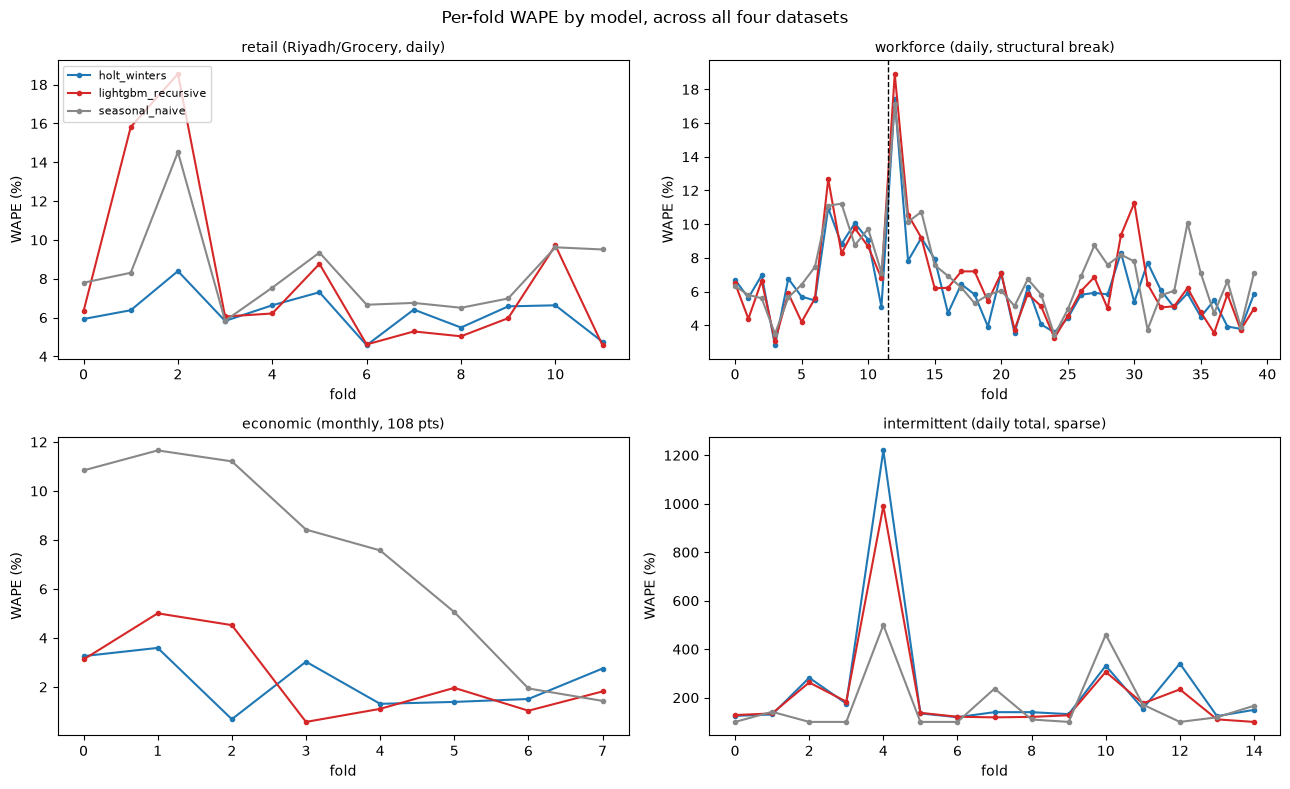

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
model_colors = {"seasonal_naive": "#888888", "holt_winters": "#1f77b4", "lightgbm_recursive": "#d62728"}

for ax, series_name in zip(axes.flat, SERIES_CONFIG.keys()):
    sub = scores[scores.series == series_name]
    for model_name, grp in sub.groupby("model"):
        ax.plot(grp["fold"], grp["wape"], marker="o", markersize=3,
                label=model_name, color=model_colors[model_name])
    if series_name == "workforce (daily, structural break)":
        splits = expanding_window_splits(
            len(SERIES_CONFIG[series_name]["values"]),
            SERIES_CONFIG[series_name]["n_folds"],
            SERIES_CONFIG[series_name]["horizon"],
            SERIES_CONFIG[series_name]["min_train_size"],
        )
        break_fold = next(i for i, (_, test) in enumerate(splits) if test.stop > BREAK_INDEX)
        ax.axvline(break_fold - 0.5, color="black", linestyle="--", linewidth=1, label="structural break")
    ax.set_title(series_name, fontsize=10)
    ax.set_xlabel("fold")
    ax.set_ylabel("WAPE (%)")

axes.flat[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Per-fold WAPE by model, across all four datasets", fontsize=12)
fig.tight_layout()
plt.show()

## Recommendation, by dataset

**Read the real leaderboard first, not intuition:** Holt-Winters won 3 of
the 4 datasets outright (economic, retail, workforce), seasonal-naive won
the 4th (intermittent), and the feature-engineered LightGBM model —
despite being the most sophisticated of the three — never won outright in
this configuration. That is worth sitting with before drawing conclusions:
it directly contradicts two tempting rules of thumb ("more data and
engineered features should beat a simple parametric model," "tree models
just need more history to shine"), and the actual numbers are the reason
to distrust both rules rather than trust either one going in.

| series | winner | mean WAPE | mean MASE |
|---|---|--:|--:|
| economic (monthly, 108 pts) | holt_winters | 2.19 | 0.399 |
| retail (Riyadh/Grocery, daily) | holt_winters | 6.24 | 0.403 |
| workforce (daily, structural break) | holt_winters | 6.40 | 1.162 |
| intermittent (daily total, sparse) | seasonal_naive | 173.75 | 0.958 |

**Economic indicator (monthly, only 108 points):** Holt-Winters edges out
LightGBM (2.19 vs 2.39 mean WAPE), and both beat seasonal-naive by a wide
margin (7.27). Notice what this does *not* show: LightGBM was **not** the
weak model here — with `lag_12` capturing the annual cycle and only a
handful of parameters to split on, it stayed close behind Holt-Winters
despite the short history. The real story is simpler than "ML needs
volume": this series is a smooth trend plus a slow business cycle, exactly
the shape Holt-Winters' additive trend+seasonal terms are built to
represent with very few parameters — it wins on fit-for-shape, not because
the alternative failed for lack of data.

**Retail (Riyadh/Grocery, daily, 3 years of clean weekly+yearly
seasonality):** Holt-Winters wins again (6.24 vs LightGBM's 8.08 and
naive's 8.28) — the opposite of the "give the model more engineered
signal and it will win" expectation. Worth connecting back to
`day1/02_lab_arima_ets.ipynb`'s single 60-day holdout, where Holt-Winters
actually *lost* to seasonal-naive on this exact series: that lab fit ETS
once, on one training window, with an optimizer that happened to converge
to `beta≈0, gamma≈0` (a near-degenerate fit). Here, Holt-Winters is
refit fresh on 12 different (larger, later) expanding-window training
sets, and clearly does not degenerate the same way on all of them — a
concrete illustration of why this whole page's backtesting-across-folds
approach exists: a single split's verdict on a model family can be an
artifact of exactly where that one split happened to fall, not a stable
property of the model.

**Workforce (daily, structural break on 2025-04-01):** the honest result
here is more specific than "the break hurts every model" — look at the
per-fold WAPE for the fold whose test window sits right at the break
(fold 12): all three models spike together, to roughly the same
magnitude (WAPE 17.1-18.9%, against a typical 4-10% everywhere else). It
is a real, one-time shock, and it hits all three model families about
equally — not a case where LightGBM's learned lag features make it
uniquely fragile. Averaged across *all* post-break folds, mean WAPE is
actually **lower** than the pre-break average for every model (holt_winters
7.81 -> 5.72, lightgbm 7.80 -> 6.15, naive 8.14 -> 6.64) — but that is a
metric artifact, not evidence the break made forecasting easier: the
post-break demand level is about 31% higher (mean actual headcount 65.9
pre vs 86.3 post), and WAPE divides by that larger number. MAE, which
doesn't have that scale-dependence, tells a flatter story pre vs post for
every model. The practical lesson for objective 7 stands regardless of
which metric you read: a single fold-12-sized shock is exactly the kind of
event a backtest average can hide, which is why this course's
`day2/04_backtesting.qmd` insists on looking at the *spread* across folds,
not just the mean — and it's the reason to monitor live forecast error
around a suspected regime change rather than trusting a historical
backtest number to still hold.

**Intermittent demand (daily total across 4 SKUs, ~82% zero rows even
after aggregating four series together):** seasonal-naive wins outright
(173.75 vs LightGBM's 216.89 and Holt-Winters' 246.79) — the one dataset
where the simplest possible baseline beats both fitted models. WAPE (not
MAPE) is doing real work here too: on a series this sparse, "repeat last
week's mostly-zero pattern" is a genuinely hard baseline to beat, and the
fitted models' extra flexibility buys little once so much of the signal
is zero-inflated noise rather than structure. This is the series
`06_model_comparison.qmd`'s decision framework should point away from
LightGBM/Holt-Winters and toward simpler baselines or
intermittent-demand-specific methods (e.g. Croston's method) that this
lab doesn't cover.

**Takeaway for objective 7:** none of this course's four tools is a
uniform winner, and the failure mode most worth guarding against is
trusting a rule of thumb ("ML needs data," "engineered features always
help," "a structural break always makes things worse") over an actual
backtest on the series in front of you. The right model family is an
empirical question, answered per series — which is the entire point of
building the comparison framework this lab just ran, rather than picking
one algorithm as the course's "best" and using it everywhere.
